# Equalizing stitched z-slice dimensions

Registered/stitched z-slices often come out at slightly different pixel
dimensions (the mosaic bounding box shifts a little from slice to slice).
Before you can stack them into a single volume every slice must share the
**same** `(height, width)`.

This notebook:

1. Loads a list of stitched image paths and **plots the distribution of their
   dimensions**.
2. Builds two equalized stacks and compares them:
   - **Method 1 — Pad:** add zero rows/cols on the **bottom & right** so every
     slice matches the **largest** height / width. Nothing is lost.
   - **Method 2 — Crop:** remove rows/cols from the **bottom & right** so every
     slice matches the **smallest** height / width. Edge content is discarded.
3. Prints how many rows/cols each slice gains (pad) or loses (crop), and shows
   per-tile visuals so you can judge how well each method works.

## 1. Configuration — point this at your stitched slices

In [1]:
from pathlib import Path

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ------------------------------------------------------------------ #
#  Option A: list the stitched z-slice paths explicitly.
# ------------------------------------------------------------------ #
STITCHED_PATHS = [
    # "qc_results/.../slice_z0000_registered.tif",
    # "qc_results/.../slice_z0001_registered.tif",
]

# ------------------------------------------------------------------ #
#  Option B: leave STITCHED_PATHS empty and auto-discover instead.
#  Every file under SEARCH_DIR matching SEARCH_GLOB is used (sorted).
# ------------------------------------------------------------------ #
SEARCH_DIR  = "qc_results"     # set to None to disable auto-discovery
SEARCH_GLOB = "*_registered.tif"

# Cap how many tiles get a per-tile visual (None = show all).
MAX_TILES_TO_SHOW = None


## 2. Resolve the file list and read each slice's dimensions

In [2]:
def resolve_paths():
    paths = [Path(p) for p in STITCHED_PATHS]
    if not paths and SEARCH_DIR is not None:
        paths = sorted(Path(SEARCH_DIR).rglob(SEARCH_GLOB))
    missing = [p for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "These paths do not exist:\n  " + "\n  ".join(map(str, missing)))
    if not paths:
        raise ValueError(
            "No images found. Fill in STITCHED_PATHS, or set SEARCH_DIR / "
            "SEARCH_GLOB to match your stitched files.")
    return paths


def read_hw(path):
    """(height, width) of a stitched slice without loading pixels if possible."""
    with tifffile.TiffFile(str(path)) as tif:
        page = tif.pages[0]
        # page.shape is the on-disk 2-D (or more) shape of the first page.
        h, w = int(page.shape[0]), int(page.shape[1])
    return h, w


paths   = resolve_paths()
shapes  = np.array([read_hw(p) for p in paths])   # (N, 2) -> (height, width)
heights = shapes[:, 0]
widths  = shapes[:, 1]

print(f"{len(paths)} stitched slices found.\n")
print(f"{'idx':>3}  {'height':>7}  {'width':>7}   file")
for i, (p, (h, w)) in enumerate(zip(paths, shapes)):
    print(f"{i:>3}  {h:>7}  {w:>7}   {p.name}")

print("\nHeight : min={}  max={}  spread={} px".format(
    heights.min(), heights.max(), heights.max() - heights.min()))
print("Width  : min={}  max={}  spread={} px".format(
    widths.min(), widths.max(), widths.max() - widths.min()))


6 stitched slices found.

idx   height    width   file
  0     6561     5575   mosaic_registered.tif
  1     6570     5541   mosaic_registered.tif
  2     6565     5537   mosaic_registered.tif
  3     6607     5616   mosaic_registered.tif
  4     6570     5541   mosaic_registered.tif
  5     6565     5537   mosaic_registered.tif

Height : min=6561  max=6607  spread=46 px
Width  : min=5537  max=5616  spread=79 px


## 3. Visualize the distribution of dimensions

A scatter of width vs. height (each point is one slice) plus marginal
histograms. The **max** corner is what padding targets; the **min** corner is
what cropping targets. The gray rectangle spans the min→max range — its size
tells you how much slices disagree.

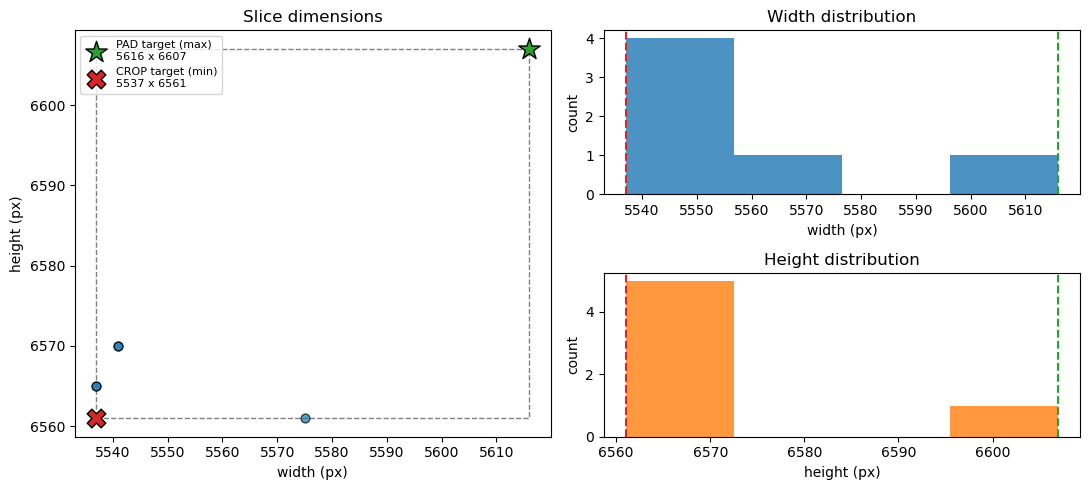

In [3]:
fig = plt.figure(figsize=(11, 5))

# --- scatter: width vs height ---
ax = fig.add_subplot(1, 2, 1)
ax.scatter(widths, heights, s=40, alpha=0.7, edgecolor="k", zorder=3)
min_w, max_w = widths.min(), widths.max()
min_h, max_h = heights.min(), heights.max()
ax.add_patch(Rectangle((min_w, min_h), max(max_w - min_w, 1e-9),
                        max(max_h - min_h, 1e-9),
                        fill=False, ls="--", ec="gray", zorder=1))
ax.scatter([max_w], [max_h], marker="*", s=260, c="tab:green",
           edgecolor="k", zorder=4, label=f"PAD target (max)\n{max_w} x {max_h}")
ax.scatter([min_w], [min_h], marker="X", s=180, c="tab:red",
           edgecolor="k", zorder=4, label=f"CROP target (min)\n{min_w} x {min_h}")
ax.set_xlabel("width (px)")
ax.set_ylabel("height (px)")
ax.set_title("Slice dimensions")
ax.legend(fontsize=8, loc="best")

# --- marginal histograms ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(widths, bins=min(20, max(3, len(set(widths.tolist())))),
         color="tab:blue", alpha=0.8)
ax2.axvline(min_w, color="tab:red", ls="--"); ax2.axvline(max_w, color="tab:green", ls="--")
ax2.set_title("Width distribution"); ax2.set_xlabel("width (px)"); ax2.set_ylabel("count")

ax3 = fig.add_subplot(2, 2, 4)
ax3.hist(heights, bins=min(20, max(3, len(set(heights.tolist())))),
         color="tab:orange", alpha=0.8)
ax3.axvline(min_h, color="tab:red", ls="--"); ax3.axvline(max_h, color="tab:green", ls="--")
ax3.set_title("Height distribution"); ax3.set_xlabel("height (px)"); ax3.set_ylabel("count")

fig.tight_layout()
plt.show()


## 4. Targets and the pad / crop amounts per slice

- **Pad (Method 1):** target = `(max_h, max_w)`. Each slice gains
  `max_h - h` rows on the bottom and `max_w - w` cols on the right.
- **Crop (Method 2):** target = `(min_h, min_w)`. Each slice loses
  `h - min_h` rows off the bottom and `w - min_w` cols off the right.

In [4]:
TARGET_MAX = (int(max_h), int(max_w))   # (height, width) for padding
TARGET_MIN = (int(min_h), int(min_w))   # (height, width) for cropping

print(f"PAD  target (largest) : {TARGET_MAX[0]} rows x {TARGET_MAX[1]} cols")
print(f"CROP target (smallest): {TARGET_MIN[0]} rows x {TARGET_MIN[1]} cols\n")

hdr = (f"{'idx':>3}  {'h x w':>13} | "
       f"{'pad rows':>8} {'pad cols':>8} | "
       f"{'cut rows':>8} {'cut cols':>8}   file")
print(hdr)
print("-" * len(hdr))
for i, (p, (h, w)) in enumerate(zip(paths, shapes)):
    pad_r, pad_c = TARGET_MAX[0] - h, TARGET_MAX[1] - w
    cut_r, cut_c = h - TARGET_MIN[0], w - TARGET_MIN[1]
    print(f"{i:>3}  {h:>5} x {w:<5} | "
          f"{pad_r:>8} {pad_c:>8} | "
          f"{cut_r:>8} {cut_c:>8}   {p.name}")

pad_rows = TARGET_MAX[0] - heights
pad_cols = TARGET_MAX[1] - widths
cut_rows = heights - TARGET_MIN[0]
cut_cols = widths  - TARGET_MIN[1]

print(f"\nPadding  adds  up to {pad_rows.max()} rows / {pad_cols.max()} cols "
      f"(mean {pad_rows.mean():.1f} / {pad_cols.mean():.1f}).")
print(f"Cropping removes up to {cut_rows.max()} rows / {cut_cols.max()} cols "
      f"(mean {cut_rows.mean():.1f} / {cut_cols.mean():.1f}).")


PAD  target (largest) : 6607 rows x 5616 cols
CROP target (smallest): 6561 rows x 5537 cols

idx          h x w | pad rows pad cols | cut rows cut cols   file
-----------------------------------------------------------------
  0   6561 x 5575  |       46       41 |        0       38   mosaic_registered.tif
  1   6570 x 5541  |       37       75 |        9        4   mosaic_registered.tif
  2   6565 x 5537  |       42       79 |        4        0   mosaic_registered.tif
  3   6607 x 5616  |        0        0 |       46       79   mosaic_registered.tif
  4   6570 x 5541  |       37       75 |        9        4   mosaic_registered.tif
  5   6565 x 5537  |       42       79 |        4        0   mosaic_registered.tif

Padding  adds  up to 46 rows / 79 cols (mean 34.0 / 58.2).
Cropping removes up to 46 rows / 79 cols (mean 12.0 / 20.8).


## 5. The two equalizing operations

In [5]:
def pad_to(img, target_hw):
    """Method 1: zero-pad the bottom & right edges up to target (h, w)."""
    th, tw = target_hw
    h, w = img.shape[:2]
    if h > th or w > tw:
        raise ValueError(f"image {img.shape[:2]} larger than pad target {target_hw}")
    pad = [(0, th - h), (0, tw - w)] + [(0, 0)] * (img.ndim - 2)
    return np.pad(img, pad, mode="constant", constant_values=0)


def crop_to(img, target_hw):
    """Method 2: cut rows/cols off the bottom & right down to target (h, w)."""
    th, tw = target_hw
    return img[:th, :tw]


# Sanity check: both operations yield a uniform stack shape.
_probe = tifffile.imread(str(paths[0]), is_ome=False)
print("padded ->", pad_to(_probe, TARGET_MAX).shape[:2], "(should equal", TARGET_MAX, ")")
print("cropped->", crop_to(_probe, TARGET_MIN).shape[:2], "(should equal", TARGET_MIN, ")")
del _probe


padded -> (6607, 5616) (should equal (6607, 5616) )
cropped-> (6561, 5537) (should equal (6561, 5537) )


## 6. Per-tile visual check

For each slice, four panels:

1. **Original** — cyan dashed box = the region **kept** by cropping; anything
   outside it (shaded red) is what Method 2 throws away.
2. **Method 1 · Padded** — on the full max-size canvas; the added zero border
   sits on the bottom/right.
3. **Method 2 · Cropped** — the min-size result.
4. **Removed by crop** — just the discarded bottom/right strips, so you can see
   whether real tissue was lost or only empty margin.

Images are downsampled for display only; the numbers above use full resolution.

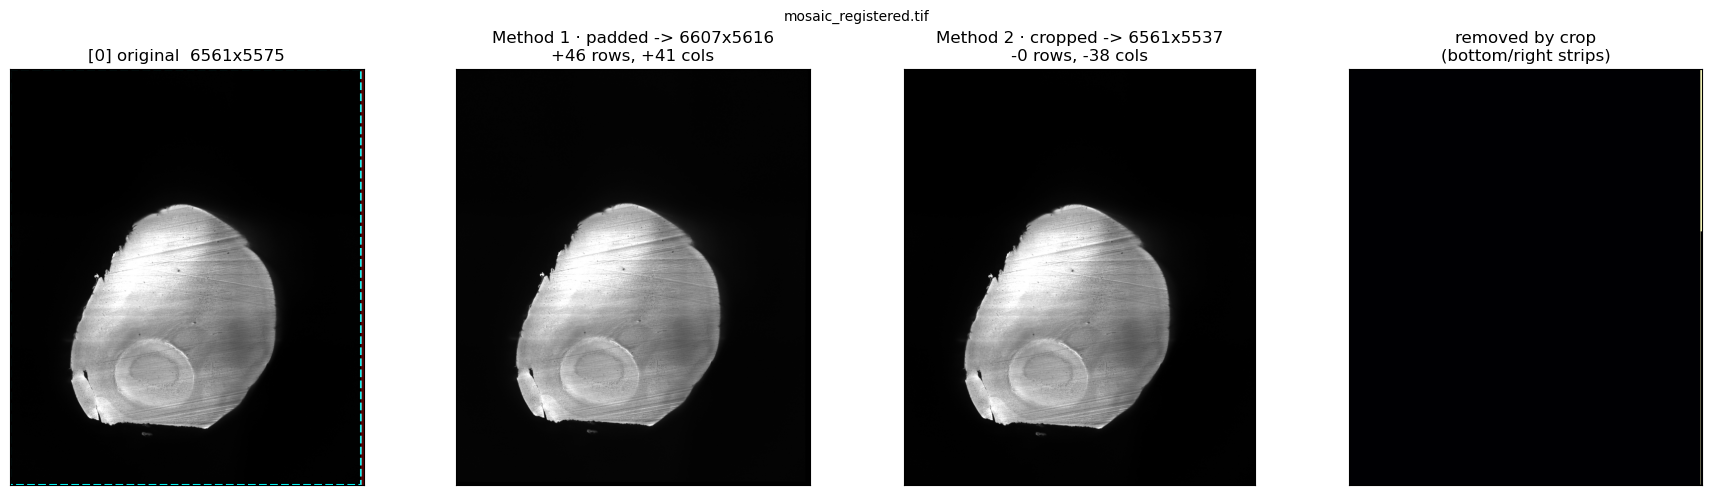

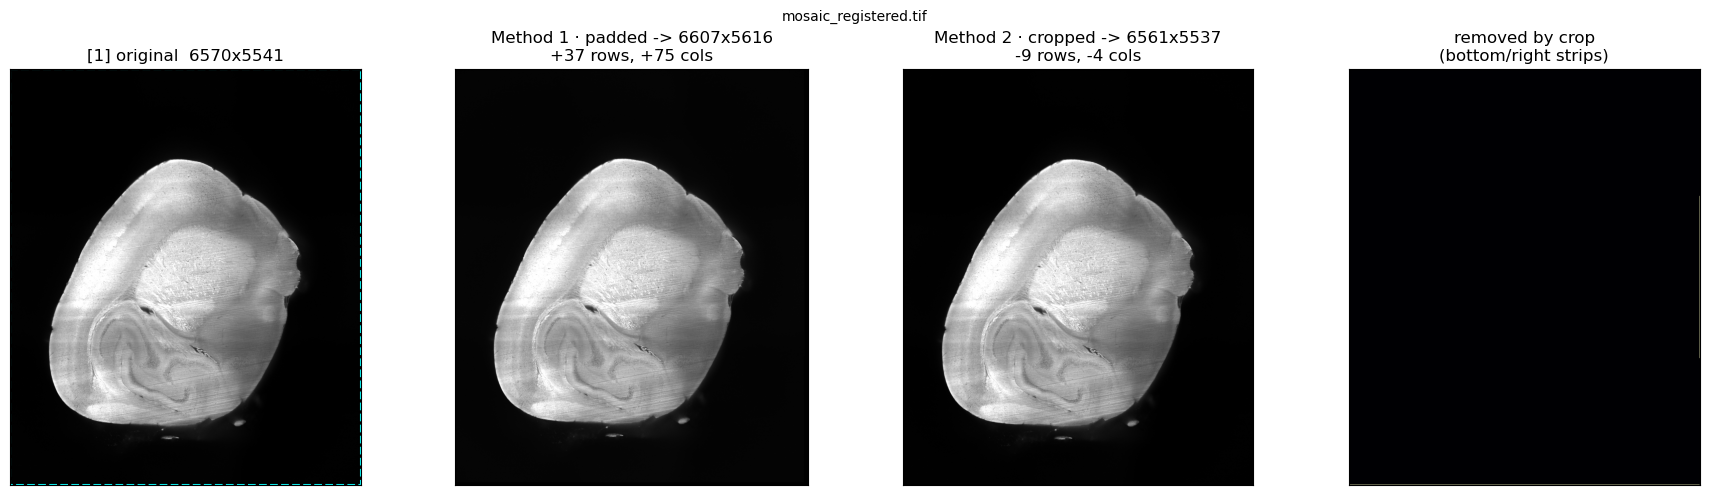

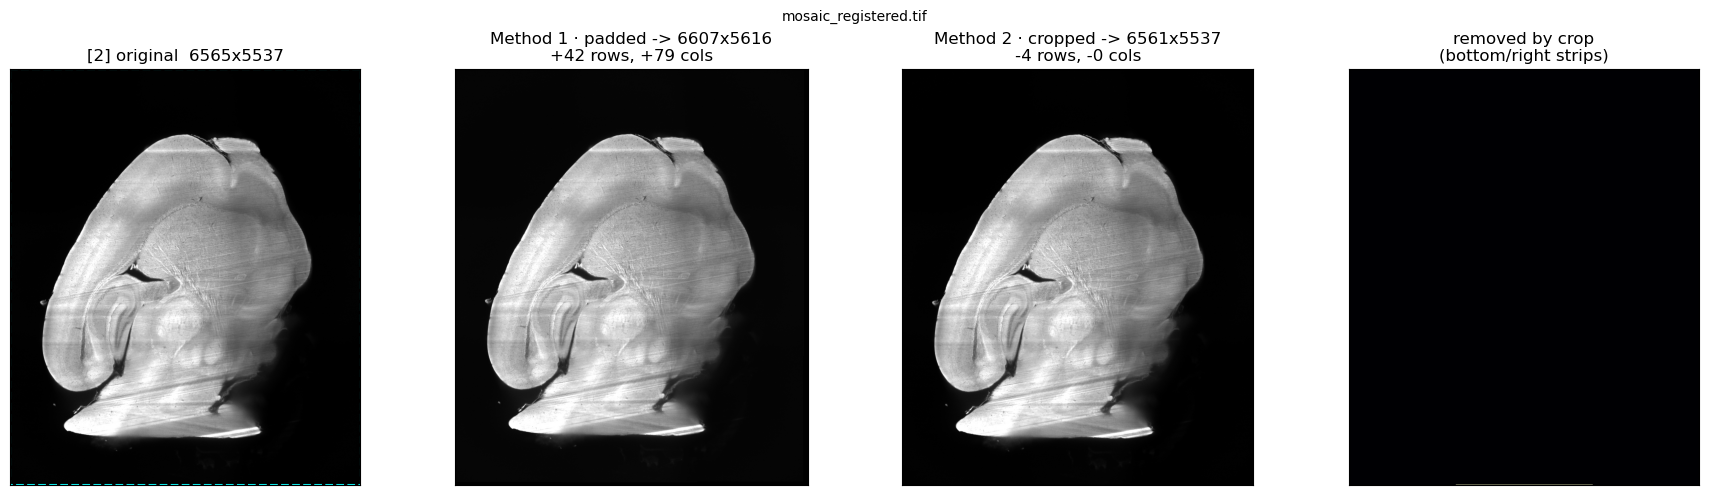

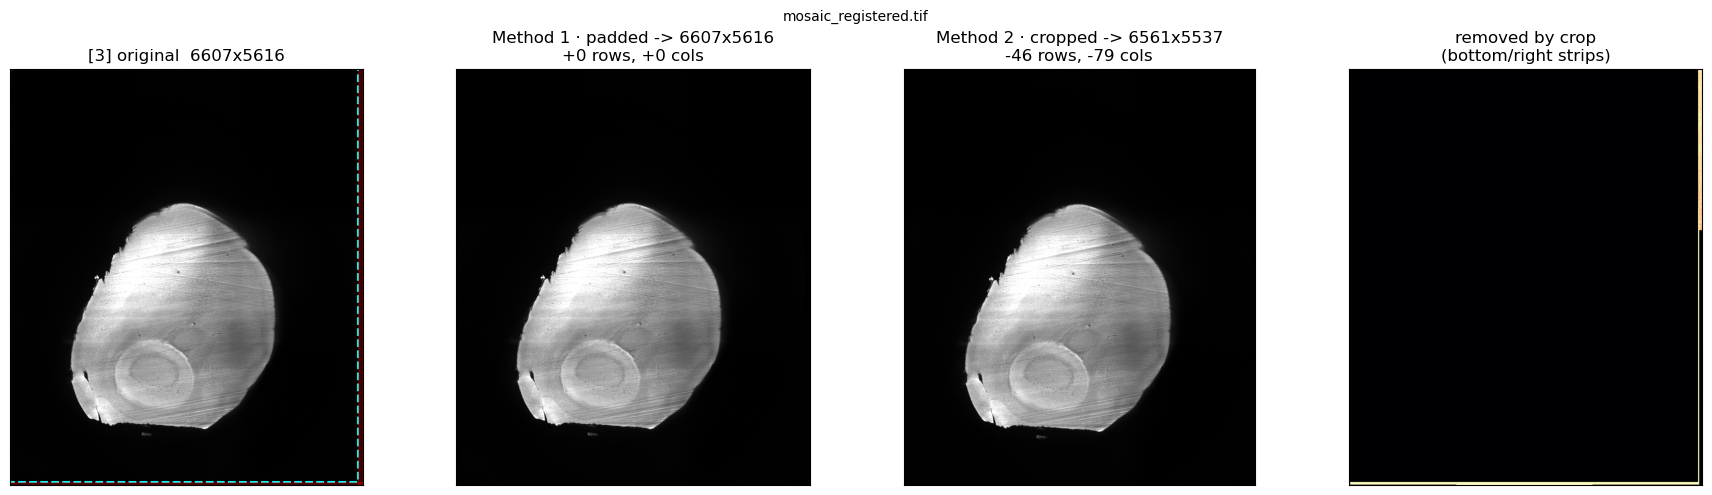

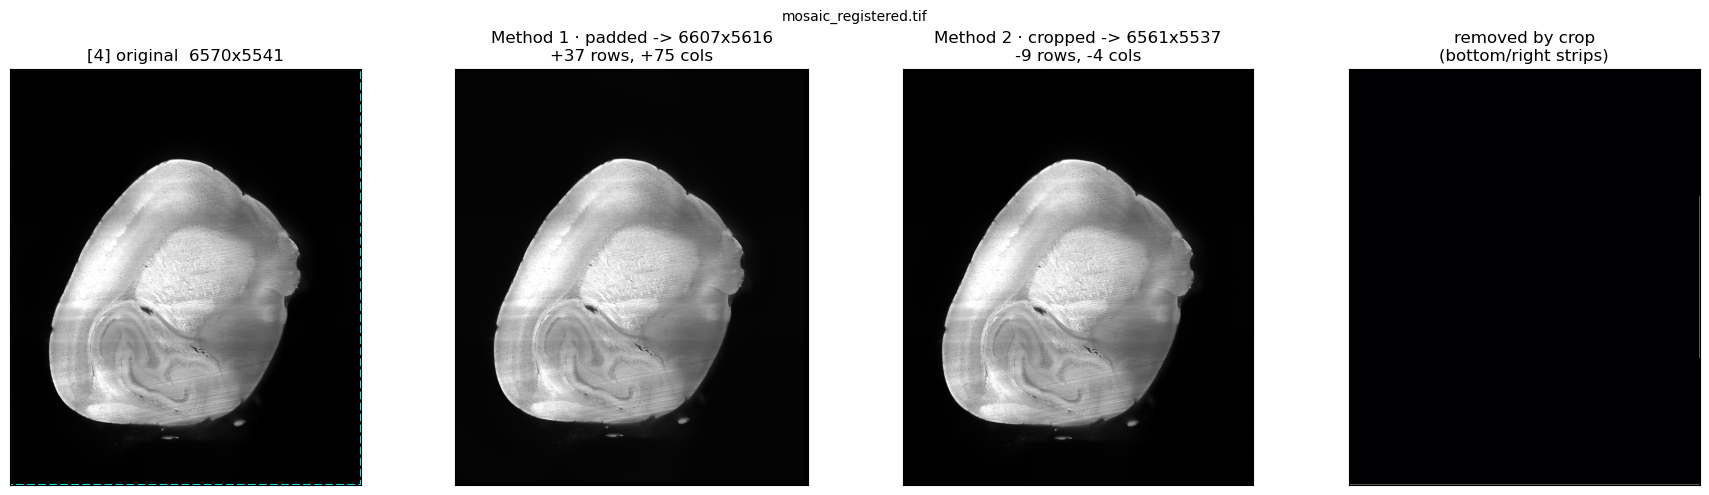

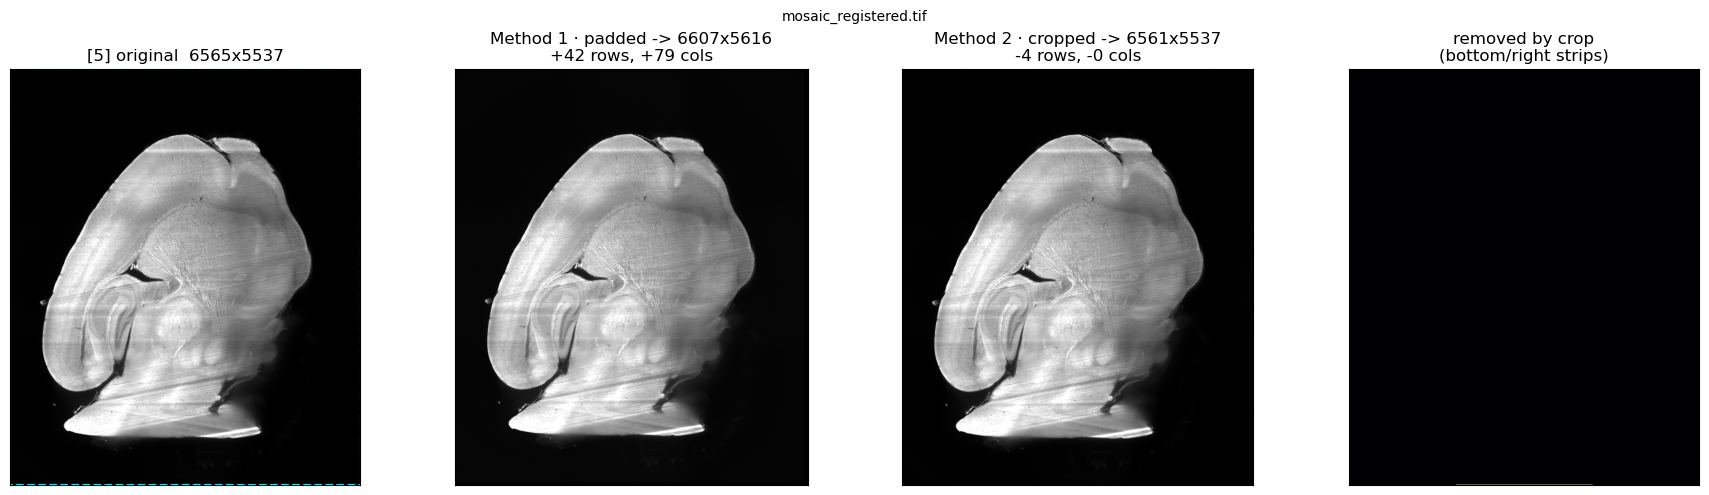

In [6]:
def to_display_2d(img):
    """Collapse to a single 2-D plane for display (handles multi-channel)."""
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        # channel-first (C,H,W) with few channels, else assume (H,W,C)
        if img.shape[0] <= 4:
            return img.max(axis=0)
        return img.max(axis=-1)
    return img.reshape(img.shape[-2], img.shape[-1])


def norm(a):
    a = a.astype("float32")
    lo, hi = np.percentile(a, (1, 99))
    if hi <= lo:
        hi = lo + 1.0
    return np.clip((a - lo) / (hi - lo), 0, 1)


def downsample(a, cap=1000):
    step = max(1, int(max(a.shape[:2]) // cap))
    return a[::step, ::step], step


show_paths = paths if MAX_TILES_TO_SHOW is None else paths[:MAX_TILES_TO_SHOW]

for i, p in enumerate(show_paths):
    img = to_display_2d(tifffile.imread(str(p), is_ome=False))
    h, w = img.shape[:2]

    padded  = pad_to(img, TARGET_MAX)
    cropped = crop_to(img, TARGET_MIN)
    cut_r, cut_c = h - TARGET_MIN[0], w - TARGET_MIN[1]
    pad_r, pad_c = TARGET_MAX[0] - h, TARGET_MAX[1] - w

    # "removed by crop" = original with the kept region blanked out
    removed = img.astype("float32").copy()
    removed[:TARGET_MIN[0], :TARGET_MIN[1]] = np.nan

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    d_img, s = downsample(norm(img))
    axes[0].imshow(d_img, cmap="gray")
    axes[0].add_patch(Rectangle((0, 0), TARGET_MIN[1] / s, TARGET_MIN[0] / s,
                                fill=False, ec="cyan", ls="--", lw=1.5))
    # shade the strips crop will remove
    if cut_c > 0:
        axes[0].add_patch(Rectangle((TARGET_MIN[1] / s, 0), (w - TARGET_MIN[1]) / s,
                                    h / s, color="red", alpha=0.25))
    if cut_r > 0:
        axes[0].add_patch(Rectangle((0, TARGET_MIN[0] / s), w / s,
                                    (h - TARGET_MIN[0]) / s, color="red", alpha=0.25))
    axes[0].set_title(f"[{i}] original  {h}x{w}")

    axes[1].imshow(downsample(norm(padded))[0], cmap="gray")
    axes[1].set_title(f"Method 1 · padded -> {TARGET_MAX[0]}x{TARGET_MAX[1]}\n"
                      f"+{pad_r} rows, +{pad_c} cols")

    axes[2].imshow(downsample(norm(cropped))[0], cmap="gray")
    axes[2].set_title(f"Method 2 · cropped -> {TARGET_MIN[0]}x{TARGET_MIN[1]}\n"
                      f"-{cut_r} rows, -{cut_c} cols")

    axes[3].imshow(downsample(norm(np.nan_to_num(removed)))[0], cmap="magma")
    axes[3].set_title(f"removed by crop\n(bottom/right strips)")

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(p.name, fontsize=10)
    fig.tight_layout()
    plt.show()


## 7. Summary — which method to use?

- **Padding** never destroys data; its only cost is extra zero border (and a
  slightly larger array). The `removed by crop` panels above show what you'd
  lose by cropping — if those strips contain real tissue, prefer padding.
- **Cropping** keeps arrays tight and every pixel real, but discards whatever
  falls outside the smallest slice. Safe only when the removed strips are empty
  margin.

Uncomment below to write out an equalized stack once you've chosen a method.

In [7]:
# --- Optional: materialize an equalized stack and save it. ---
# METHOD = "pad"   # or "crop"
# op, target = (pad_to, TARGET_MAX) if METHOD == "pad" else (crop_to, TARGET_MIN)
# stack = np.stack([op(tifffile.imread(str(p), is_ome=False), target) for p in paths])
# print("equalized stack:", stack.shape, stack.dtype)
# tifffile.imwrite(f"stitched_equalized_{METHOD}.tif", stack)
